In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE

In [2]:
with open("code_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)
with open("eval_questions.json", "r", encoding="utf-8") as f:
    questions = json.load(f)
with open("categories.json", "r", encoding="utf-8") as f:
    categories = json.load(f)

print(f"Количество фрагментов кода: {len(corpus)}")
print(f"Количество вопросов: {len(questions)}")

Количество фрагментов кода: 200
Количество вопросов: 25


In [3]:
documents = [
    (
        f"Function: {item['function_name']}\n"
        f"Category: {item['category']}\n"
        f"Description: {item['description']}\n"
        f"Code:\n{item['code']}"
    )
    for item in corpus
]
chunk_ids = [item["id"] for item in corpus]

print("Пример документа:\n")
print(documents[0][:500])

Пример документа:

Function: verify_jwt_token
Category: auth
Description: Проверяет JWT-токен и возвращает payload или причину невалидности.
Code:
def verify_jwt_token(token: str, secret: str) -> dict:
    """Проверяет JWT-токен и возвращает payload или причину невалидности."""
    try:
        payload = jwt.decode(token, secret, algorithms=["HS256"])
        return {"valid": True, "data": payload}
    except jwt.ExpiredSignatureError:
        return {"valid": False, "error": "expired"}
    except jwt.InvalidToken


In [4]:
models = {
    "MiniLM": SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"),
    "MPNet": SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"),
    "DistilUSE": SentenceTransformer("distiluse-base-multilingual-cased-v2")
}
print("Модели загружены")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Модели загружены


In [8]:
def evaluate_model(model):
    print("Создание эмбеддингов корпуса...")
    corpus_embeddings = model.encode(
        documents,
        convert_to_tensor=True,
        show_progress_bar=True
    )
    correct_answers = 0
    for q in questions:
        query_embedding = model.encode(q["query"],convert_to_tensor=True)
        similarities = util.cos_sim(query_embedding,corpus_embeddings)[0]
        top3_idx = np.argsort(similarities.cpu().numpy())[-3:][::-1]
        top3_ids = [chunk_ids[i]for i in top3_idx]
        if q["correct_chunk_id"] in top3_ids:
            correct_answers += 1
    precision_at_3 = (correct_answers / len(questions))
    return precision_at_3, corpus_embeddings
results = {}
embeddings_store = {}
for model_name, model in models.items():
    print("\n" + "=" * 50)
    print(f"Оценка модели: {model_name}")
    precision, embeddings = evaluate_model(model)
    results[model_name] = precision
    embeddings_store[model_name] = embeddings
    print(f"Precision@3 для {model_name}: "f"{precision:.4f}")


Оценка модели: MiniLM
Создание эмбеддингов корпуса...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Precision@3 для MiniLM: 0.8400

Оценка модели: MPNet
Создание эмбеддингов корпуса...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Precision@3 для MPNet: 0.8800

Оценка модели: DistilUSE
Создание эмбеддингов корпуса...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Precision@3 для DistilUSE: 0.8000


In [9]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Precision@3": list(results.values())
})
results_df = results_df.sort_values(by="Precision@3",ascending=False)
results_df
best_model_name = max(results,key=results.get)
best_score = results[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"Precision@3 = {best_score:.4f}")

Лучшая модель: MPNet
Precision@3 = 0.8800


t-SNE завершён


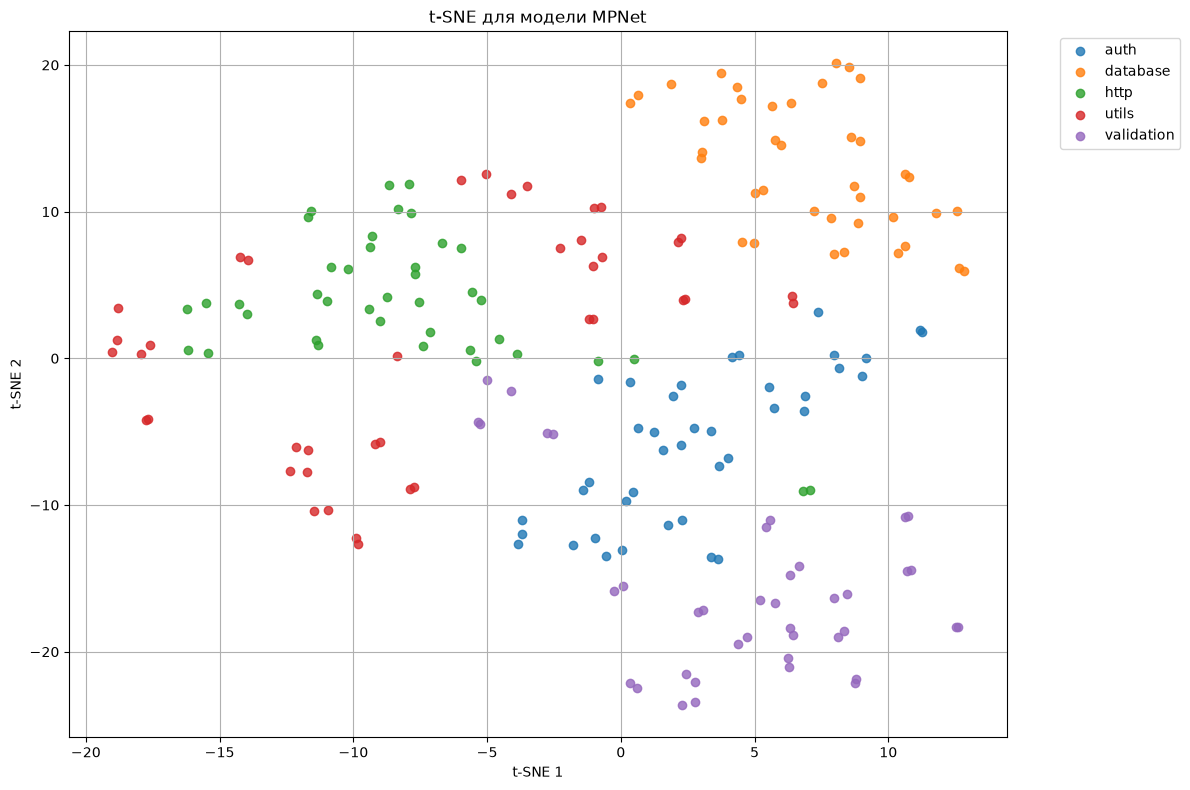

In [10]:
best_embeddings = embeddings_store[best_model_name].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(best_embeddings)

print("t-SNE завершён")

plt.figure(figsize=(12, 8))
categories_list = [item["category"] for item in corpus]
unique_categories = sorted(list(set(categories_list)))

for category in unique_categories:
    idx = [i for i, c in enumerate(categories_list) if c == category]
    plt.scatter(coords[idx, 0], coords[idx, 1], label=category, alpha=0.8)

plt.title(f"t-SNE для модели {best_model_name}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
best_model = models[best_model_name]
corpus_embeddings = best_model.encode(documents,convert_to_tensor=True)
mistakes = []
for q in questions:
    query_embedding = best_model.encode(q["query"],convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding,corpus_embeddings)[0]
    top3_idx = np.argsort(similarities.cpu().numpy())[-3:][::-1]
    top3_ids = [chunk_ids[i]for i in top3_idx]
    if q["correct_chunk_id"] not in top3_ids:
        language = q["language"]
        correct_category = next(item["category"]for item in corpus if item["id"] == q["correct_chunk_id"])
        mistakes.append({
            "Запрос": q["query"],
            "Язык": language,
            "Категория": correct_category,
            "Правильный id": q["correct_chunk_id"],
            "Top-3 модели": ", ".join(top3_ids)
        })

mistakes_df = pd.DataFrame(mistakes)
print(f"Количество ошибок: {len(mistakes_df)}")
display(mistakes_df)
print("\nОшибки по категориям:")
display(mistakes_df["Категория"].value_counts())
print("\nОшибки по языкам:")
display(mistakes_df["Язык"].value_counts())

Количество ошибок: 3


,Запрос,Язык,Категория,Правильный id,Top-3 модели
0,"как проверить, истёк ли токен?",ru,auth,func_001,"func_166, func_066, func_071"
1,проверить права администратора на эндпоинте,ru,auth,func_109,"func_008, func_009, func_108"
2,compute file hash for verification,en,utils,func_192,"func_103, func_092, func_003"



Ошибки по категориям:


Категория
auth     2
utils    1
Name: count, dtype: int64


Ошибки по языкам:


Язык
ru    2
en    1
Name: count, dtype: int64

In [12]:
best_model = models[best_model_name]
corpus_embeddings = best_model.encode(documents,convert_to_tensor=True)
ru_correct = 0
en_correct = 0
ru_total = 0
en_total = 0
for q in questions:
    query_embedding = best_model.encode(q["query"],convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding,corpus_embeddings)[0]
    top3_idx = np.argsort(similarities.cpu().numpy())[-3:][::-1]
    top3_ids = [chunk_ids[i]for i in top3_idx]
    if q["language"] == "ru":
        ru_total += 1
        if q["correct_chunk_id"] in top3_ids:
            ru_correct += 1
    else:
        en_total += 1
        if q["correct_chunk_id"] in top3_ids:
            en_correct += 1
comparison = pd.DataFrame({"Язык":["Русский","Английский"],"Precision@3":[ru_correct / ru_total,en_correct / en_total]})
display(comparison)

,Язык,Precision@3
0,Русский,0.866667
1,Английский,0.900000


In [15]:
print("ФИНАЛЬНЫЙ ВЫВОД")
print("=" * 60)
print(
    "В ходе исследования были сравнены три мультиязычные  "
    "эмбеддинг-модели: paraphrase-multilingual-MiniLM-L12-v2, "
    "distiluse-base-multilingual-cased-v2 и "
    "paraphrase-multilingual-mpnet-base-v2."
)
print(
    f"Лучший результат показала модель {best_model_name} "
    f"с Precision@3 = {best_score:.4f}."
)
print(
    "Это означает, что данная модель чаще находила правильный "
    "фрагмент кода среди трёх наиболее релевантных результатов поиска."
)
print(
    "Дополнительный анализ ошибок позволил определить запросы, "
    "для которых поиск оказался менее точным, а также сравнить "
    "качество поиска для русскоязычных и англоязычных запросов."
)
print(
    "Визуализация t-SNE показала формирование смысловых кластеров "
    "между различными категориями программного кода."
)
print(
    f"По результатам эксперимента наиболее подходящей моделью "
    f"для семантического поиска является {best_model_name}."
)

ФИНАЛЬНЫЙ ВЫВОД
В ходе исследования были сравнены три мультиязычные  эмбеддинг-модели: paraphrase-multilingual-MiniLM-L12-v2, distiluse-base-multilingual-cased-v2 и paraphrase-multilingual-mpnet-base-v2.
Лучший результат показала модель MPNet с Precision@3 = 0.8800.
Это означает, что данная модель чаще находила правильный фрагмент кода среди трёх наиболее релевантных результатов поиска.
Дополнительный анализ ошибок позволил определить запросы, для которых поиск оказался менее точным, а также сравнить качество поиска для русскоязычных и англоязычных запросов.
Визуализация t-SNE показала формирование смысловых кластеров между различными категориями программного кода.
По результатам эксперимента наиболее подходящей моделью для семантического поиска является MPNet.


In [14]:
print("ТАБЛИЦА РЕЗУЛЬТАТОВ")
results_df = pd.DataFrame({
    "Модель": list(results.keys()),
    "Precision@3": list(results.values())
})
results_df = results_df.sort_values(by="Precision@3",ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Место"
print("Сравнение моделей:\n")
display(results_df)

ТАБЛИЦА РЕЗУЛЬТАТОВ
Сравнение моделей:



,Модель,Precision@3
Место,,
1,MPNet,0.88
2,MiniLM,0.84
3,DistilUSE,0.80
